In [1]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
df = spark.read.table("qa_testing_clean")

pdf = df.toPandas()

pdf.head()


StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 3, Finished, Available, Finished, False)

,Test_ID,Test_Date,Game_Name,Tester_Name,Testing_Phase,QA_Notes_Raised,QA_Notes_Resolved,Bugs_Found,Severity_Level,Completion_Percentage,Test_Duration_Hours,Platform,Release_Version,Test_Status,QA_Resolution_Rate
0,TST-10295,2025-05-08,Fortune Reels,Xolani N.,Sanity,0,0,2,Medium,78.11,2.84,Web,v5.5,Failed,0.0
1,TST-10312,2025-05-17,Mystic Empire,Xolani N.,Regression,3,3,0,Low,88.34,3.35,Desktop,v2.9,Failed,100.0
2,TST-10520,2025-02-14,Galaxy Quest,Xolani N.,Smoke,6,6,5,Low,86.61,3.82,Web,v3.2,Failed,100.0
3,TST-10766,2025-03-19,Mega Spin Arena,Xolani N.,UAT,5,5,2,Low,87.07,3.71,Web,v5.7,Blocked,100.0
4,TST-10795,2025-02-01,Mega Spin Arena,Xolani N.,Smoke,0,0,1,Low,97.75,5.27,Desktop,v5.5,Failed,0.0


In [2]:
pdf["High_QA_Risk"] = (pdf["QA_Notes_Raised"] > 5).astype(int)

pdf[["QA_Notes_Raised", "High_QA_Risk"]].head()

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 5, Finished, Available, Finished, False)

,QA_Notes_Raised,High_QA_Risk
0,0,0
1,3,0
2,6,1
3,5,0
4,0,0


In [3]:
features = [
    "Bugs_Found",
    "Test_Duration_Hours",
    "Completion_Percentage"
]

X = pdf[features]
y = pdf["High_QA_Risk"]


StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 6, Finished, Available, Finished, False)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 7, Finished, Available, Finished, False)

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 8, Finished, Available, Finished, False)

RandomForestClassifier()

In [6]:
predictions = model.predict(X_test)

predictions[:10]

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 9, Finished, Available, Finished, False)

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 1])

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 10, Finished, Available, Finished, False)

Model Accuracy: 0.543


In [9]:
import matplotlib.pyplot as plt

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 12, Finished, Available, Finished, False)

In [11]:
import pandas as pd

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 14, Finished, Available, Finished, False)

In [12]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

importance

StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 15, Finished, Available, Finished, False)

,Feature,Importance
0,Bugs_Found,0.050020
2,Completion_Percentage,0.460078
1,Test_Duration_Hours,0.489902


StatementMeta(, 5f14d256-0a49-4e43-ad0d-341d37de0042, 20, Finished, Available, Finished, False)

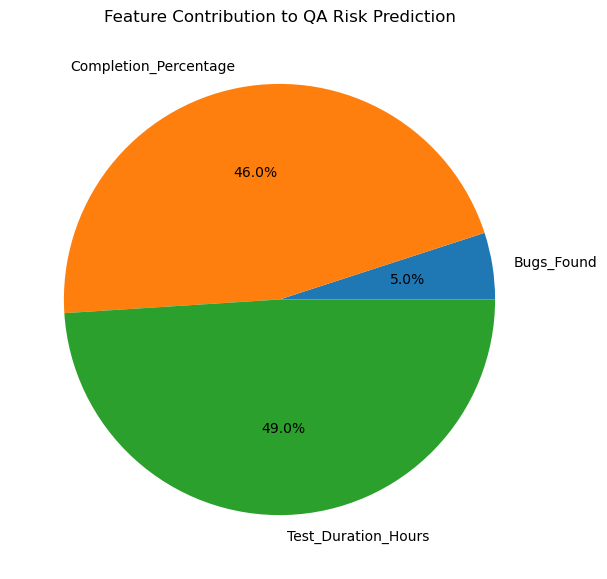

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    importance["Importance"],
    labels=importance["Feature"],
    autopct='%1.1f%%'
)

plt.title("Feature Contribution to QA Risk Prediction")

plt.show()